# Decision Trees

- Decisision Trees are commonly used in Machine Learning among classification, regression and even multioutput tasks

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]]
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [2]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf, 
    out_file="iris_tree.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

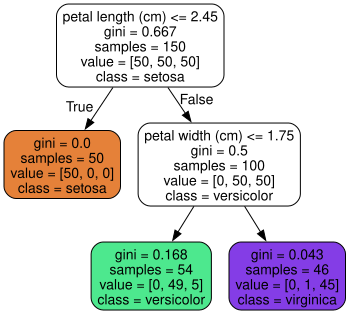

In [3]:
from graphviz import Source
Source.from_file("iris_tree.dot")

Steps that decision tree to make a prediction: 
1. Check `petal length (cm) <= 2.45`, if yes, down left, not down right
2. After going right, check `petal width (cm) <= 1.75`, if yes, down left, not down right
3. Last nodes represents each class, `samples` are the number of samples which satisfies the conditions above

`DecisionTree` classifier uses `gini` impurity by default, this parameter carries the value that if samples in that node are of the same class then equal to 0 otherwise, the value can go up to 1 which is impure by definition 

- White box models - decision trees, easly exaplainable and interpretable
- Black box models - random forests, neural netoworks, explaining how predictions being done is hard

- Decision Trees can be used to predict probabilty for each class
- For example, if we pass 5 and 1.5 as length and width features of petal, we can get problity scores for each class in output using `predict_proba()` method

In [5]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([[0.   , 0.907, 0.093]])

## Regularization Hyperparameters

In [31]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=6, random_state=42)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

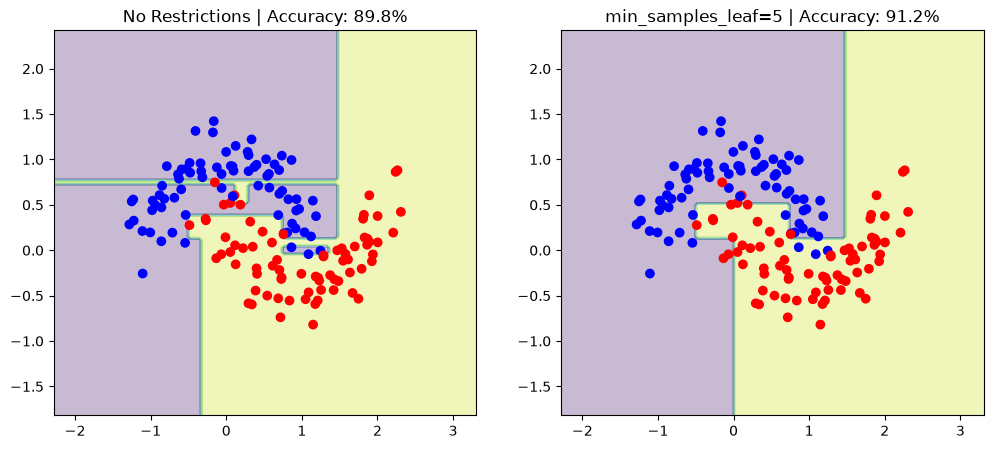

In [41]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

models = (
    (0, "No Restrictions", tree_clf1),
    (1, "min_samples_leaf=5", tree_clf2),
)

X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2, random_state=43)

for idx, title, model in models:
    acc = model.score(X_moons_test, y_moons_test) * 100
    ax[idx].set_title(f"{title} | Accuracy: {acc}%")
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_moons,
        response_method="predict",
        alpha=0.3,
        ax=ax[idx]
    )
    ax[idx].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="bwr")
    
    


Two graphs above plots same generated dataset but `DecisionTreeClassifier` with different regularization hyperparametr. Second model's `min_samples_leaf=5` so it generalized better training data as decision boundary splitting blue and red dots. In contrast, first model overfits training data that it tried to learn every data samples location as shown in the first grapgh

## Regression

Let's make quadratic dataset using numpy to train simple `DecisionTreeRegression` model 

In [77]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5  # a single random input feature
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)

# Generate values across the feature range
X_plot = np.linspace(
    X_quad.min(),
    X_quad.max(),
    500
).reshape(-1, 1)


we gonna try several differnt hyperparameters to compare model performance so make training part as function

In [89]:
def train_predict_reg_tree(max_depth=None, min_samples_leaf=1):
    
    tree_reg = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
    tree_reg.fit(X_quad, y_quad)
    
    y_pred = tree_reg.predict(X_plot)
    
    return tree_reg, y_pred
    

Like in classficationm, we can plot regression tree in the graph as well

In [86]:

from sklearn.tree import export_graphviz

tree_reg, _ = train_predict_reg_tree(X_plot, 2)

export_graphviz(
    tree_reg, 
    out_file="qd_reg_tree.dot",
    feature_names=["x1"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

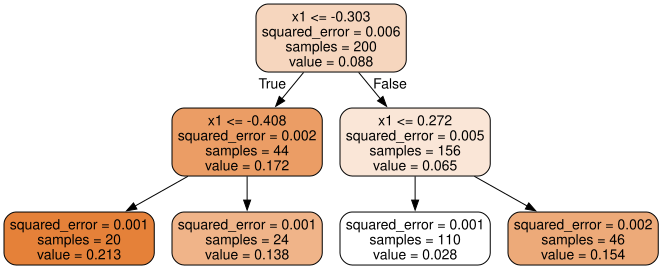

In [88]:
from graphviz import Source

Source.from_file("qd_reg_tree.dot")

Visualizing three models with different hyperparameters

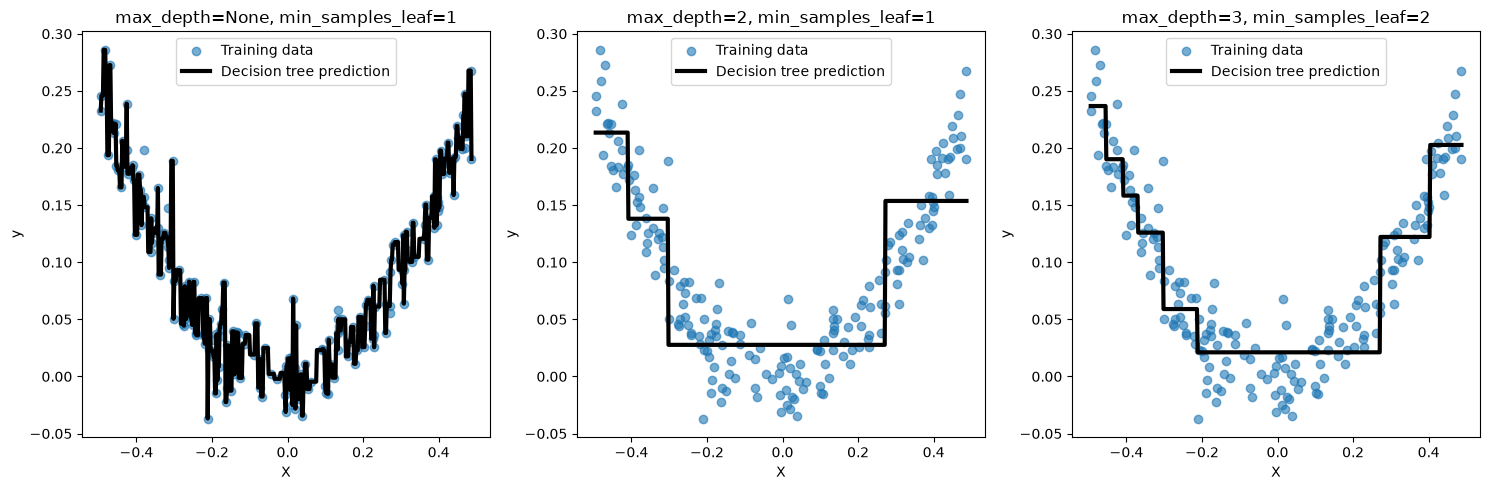

In [94]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

models_params = (
    (0, {"max_depth": None, "min_samples_leaf": 1}),
    (1, {"max_depth": 2, "min_samples_leaf": 1}),
    (2, {"max_depth": 3, "min_samples_leaf": 2}),
)

for idx, param in models_params:
    tree_reg, y_pred = train_predict_reg_tree(**param)

    ax[idx].scatter(
        X_quad,
        y_quad,
        alpha=0.6,
        label="Training data"
    )

    ax[idx].plot(
        X_plot,
        y_pred,
        linewidth=3,
        color="black",
        label="Decision tree prediction"
    )

    ax[idx].set_xlabel("X")
    ax[idx].set_ylabel("y")
    ax[idx].set_title(
        f"max_depth={param['max_depth']}, "
        f"min_samples_leaf={param['min_samples_leaf']}"
    )
    ax[idx].legend()

plt.tight_layout()
plt.show()

We have train three `DecisionTreeRegressor` models with different hyper parameters:
- First model does not have any restrictions because we did not set any parameter, so it is OVERFITTING
- Second model's `max_depth` parameter was set to 2 which is very small, so it is UNDERFITTING
- Third model's `max_depth` is higher so it is now generalizing well